$\Huge \rm Causality$

Francisco Förster Burón, MDS7201

# Simpson's paradox

Simpson's paradox is a phenomenon in probability and statistics in which a trend appears in several groups of data but disappears or reverses when the groups are combined.

![](Simpsons_paradox_-_animation.gif)

Example: UC Berkeley gender bias

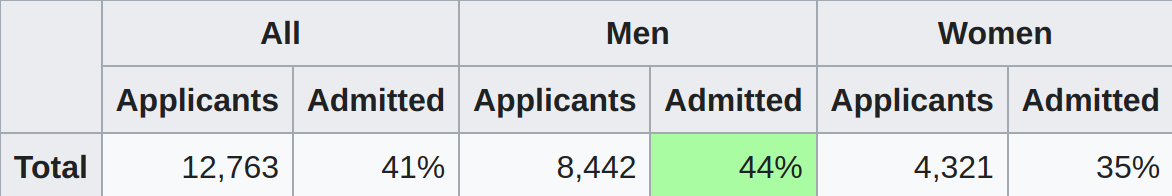

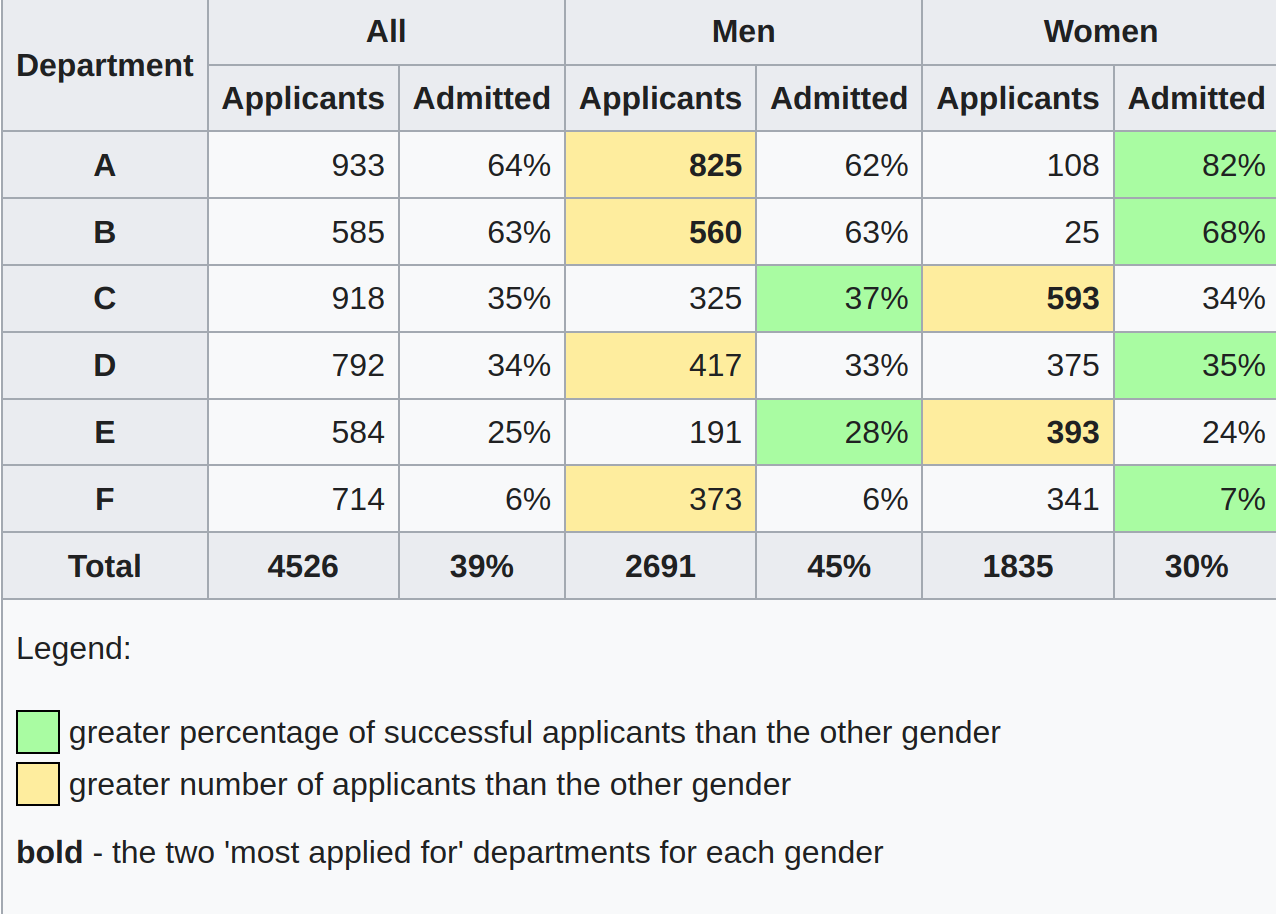

The correlation between number of applicants per gender and the department admission rates led to an apparent bias.

# Correlation vs. Causation

## Objectives

- Understand the difference between correlation and causation.
- Learn how spurious correlations can mislead conclusions.
- Simulate and visualize examples using Python.


## Setup

In [127]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## Simulating Spurious Correlation

In [128]:
np.random.seed(42)
n = 200

# Hidden confounder: temperature
temperature = np.random.normal(loc=25, scale=5, size=n)

# Ice cream sales increase with temperature
ice_cream_sales = temperature * 10 + np.random.normal(0, 5, size=n)

# Shark attacks also increase with temperature (more people swim)
shark_attacks = temperature * 2 + np.random.normal(0, 2, size=n)

df = pd.DataFrame({
    'Temperature': temperature,
    'IceCreamSales': ice_cream_sales,
    'SharkAttacks': shark_attacks
})

## Correlation Between Variables

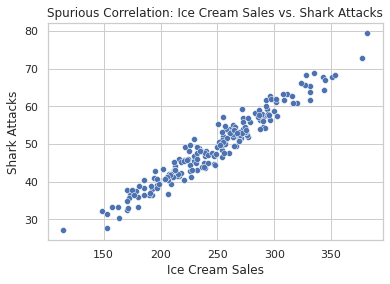

Correlation matrix:
               IceCreamSales  SharkAttacks
IceCreamSales       1.000000      0.971348
SharkAttacks        0.971348      1.000000


In [129]:
sns.scatterplot(x='IceCreamSales', y='SharkAttacks', data=df)
plt.title("Spurious Correlation: Ice Cream Sales vs. Shark Attacks")
plt.xlabel("Ice Cream Sales")
plt.ylabel("Shark Attacks")
plt.show()

print("Correlation matrix:")
print(df[['IceCreamSales', 'SharkAttacks']].corr())

## Controlling for a Confounder

In [130]:
import statsmodels.api as sm

X = df[['IceCreamSales', 'Temperature']]
X = sm.add_constant(X)
y = df['SharkAttacks']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           SharkAttacks   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                     2076.
Date:                Tue, 14 Oct 2025   Prob (F-statistic):          4.14e-133
Time:                        14:43:25   Log-Likelihood:                -418.86
No. Observations:                 200   AIC:                             843.7
Df Residuals:                     197   BIC:                             853.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             1.2331      0.763      1.617

##  Summary

- Correlation does **not imply** causation.
- **Confounders** can lead to misleading associations.
- **Statistical control** can reveal the true relationships. If linear relation, linear model can be used to extract true causal dependencies.


# Directed Acyclic Graphs (DAGs)

##  Objectives
- Understand how to represent causal relationships with DAGs.
- Learn about nodes, edges, and how direction encodes causality.
- Explore examples of causal reasoning using graphs.


##  Setup

In [132]:
import networkx as nx
import matplotlib.pyplot as plt

In [133]:
def draw_dag(edges, labels=None, title="Causal DAG"):
    G = nx.DiGraph()
    G.add_edges_from(edges)
    pos = nx.spring_layout(G, seed=42)

    fig, ax = plt.subplots(figsize=(8, 5))
    nx.draw_networkx(G, pos, ax=ax, arrows=True, with_labels=True,
                     node_size=2000, node_color='lightblue', font_size=12)
    if labels:
        edge_labels = {(u, v): l for (u, v), l in zip(edges, labels)}
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax)

    ax.set_title(title)
    ax.axis("off")
    plt.show()


## A Simple Causal Graph

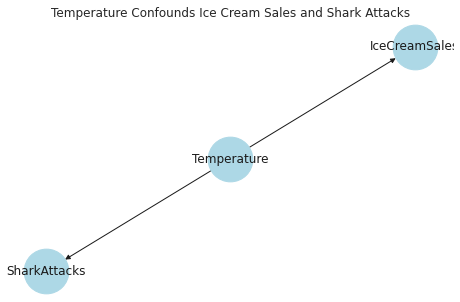

In [134]:
edges = [('Temperature', 'IceCreamSales'), ('Temperature', 'SharkAttacks')]
draw_dag(edges, title="Temperature Confounds Ice Cream Sales and Shark Attacks")

## Causal Chains and Colliders

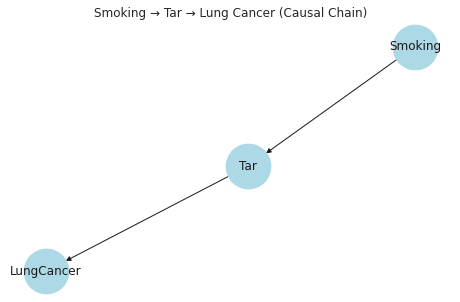

In [136]:
edges_chain = [('Smoking', 'Tar'), ('Tar', 'LungCancer')]
draw_dag(edges_chain, title="Smoking → Tar → Lung Cancer (Causal Chain)")

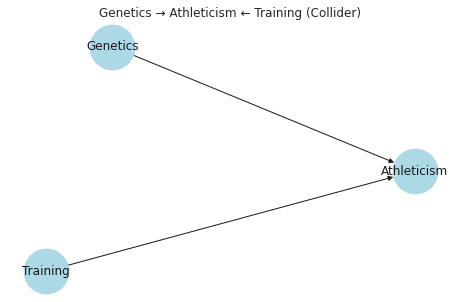

In [137]:
edges_collider = [('Genetics', 'Athleticism'), ('Training', 'Athleticism')]
draw_dag(edges_collider, title="Genetics → Athleticism ← Training (Collider)")

## The Backdoor Path

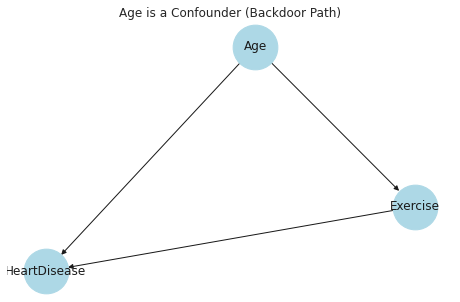

In [11]:
edges_backdoor = [('Age', 'Exercise'), ('Age', 'HeartDisease'), ('Exercise', 'HeartDisease')]
draw_dag(edges_backdoor, title="Age is a Confounder (Backdoor Path)")

## Summary

- **Nodes** represent variables.
- **Edges** represent potential causal effects.
- DAGs help identify **confounding**, **colliders**, and **causal chains**.
- You can use them to decide what to control for when estimating causal effects.

Next: We'll learn about **d-separation** and **adjustment** using these graphs!


## Why Do Colliders, Confounders, and Chains Matter?

In causal inference, **the structure of the causal graph determines how we should analyze the data** to estimate causal effects correctly. Here's why the key patterns matter:

---

### 🔱 **Confounders (Forks)**
Structure: `A ← C → B`

- A confounder is a **common cause** of both treatment and outcome.
- **Failure to adjust** for confounders can lead to **spurious correlations** (confounding bias).
- **Solution:** Identify confounders and control for them (e.g., using stratification, regression, or matching).

**Example:**  
If `Genetics` affects both `Smoking` and `Heart Disease`, failing to adjust for it would misattribute some genetic risk to smoking.

---

### 🔗 **Chains (Mediators)**
Structure: `A → B → C`

- The middle node `B` is a **mediator** of the causal effect from `A` to `C`.
- Conditioning on a mediator **blocks** part of the causal path.
- You **should not control** for mediators if your goal is to estimate the total effect of `A` on `C`.

**Example:**  
If `Smoking → Tar → Lung Cancer`, adjusting for `Tar` blocks part of the true effect of smoking on cancer.

---

### 🎯 **Colliders**
Structure: `A → C ← B`

- Colliders are **common effects** of two variables.
- Conditioning on a collider **opens** a path that otherwise doesn’t exist.
- This can introduce **collider bias** or **selection bias**.

**Example:**  
If both `Talent` and `Luck` influence `Fame`, selecting only famous people (conditioning on the collider) induces a false correlation between `Talent` and `Luck`.

---

###  Summary Table

| Structure   | Form              | Condition on middle? | Effect                                |
|-------------|-------------------|-----------------------|----------------------------------------|
| Confounder  | A ← C → B         | ✅ Yes                | Removes spurious correlation           |
| Mediator    | A → B → C         | ❌ No                 | Blocks part of the causal effect       |
| Collider    | A → C ← B         | ❌ No                 | Introduces spurious correlation (bias) |


# d-Separation and Conditional Independence

##  Objectives
- Learn what d-separation is and how it applies to causal inference.
- Understand paths: chains, forks (confounding), and colliders.
- Practice identifying when variables are conditionally independent.


##  Setup

In [15]:
import networkx as nx
import matplotlib.pyplot as plt

In [16]:
def draw_dag(edges, labels=None, title="Causal DAG"):
    G = nx.DiGraph()
    G.add_edges_from(edges)
    pos = nx.spring_layout(G, seed=42)

    fig, ax = plt.subplots(figsize=(8, 5))
    nx.draw_networkx(G, pos, ax=ax, arrows=True, with_labels=True,
                     node_size=2000, node_color='lightblue', font_size=12)
    if labels:
        edge_labels = {(u, v): l for (u, v), l in zip(edges, labels)}
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax)

    ax.set_title(title)
    ax.axis("off")
    plt.show()

## What is d-Separation?

d-Separation tells us whether two nodes (variables) are conditionally independent, given a set of observed variables.

Three important structures:
- **Chain**: A → B → C
- **Fork** (common cause): A ← B → C
- **Collider** (common effect): A → B ← C


## 🔗 Chain Structure

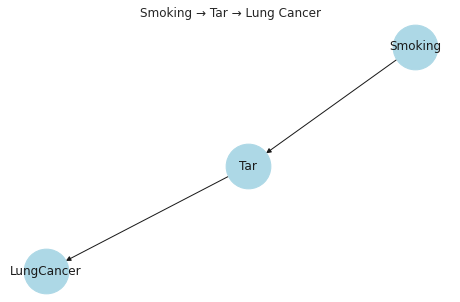

In [17]:
edges_chain = [('Smoking', 'Tar'), ('Tar', 'LungCancer')]
draw_dag(edges_chain, title="Smoking → Tar → Lung Cancer")

If you observe **Tar**, Smoking and Lung Cancer become conditionally independent.

**Interpretation**: `Smoking ⊥ LungCancer | Tar`

## 🔱 Fork (Confounding) Structure

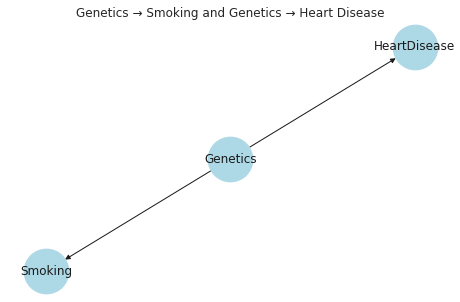

In [18]:
edges_fork = [('Genetics', 'HeartDisease'), ('Genetics', 'Smoking')]
draw_dag(edges_fork, title="Genetics → Smoking and Genetics → Heart Disease")

If you observe **Genetics**, Smoking and Heart Disease become conditionally independent.

**Interpretation**: `Smoking ⊥ HeartDisease | Genetics`

## 🎯 Collider Structure

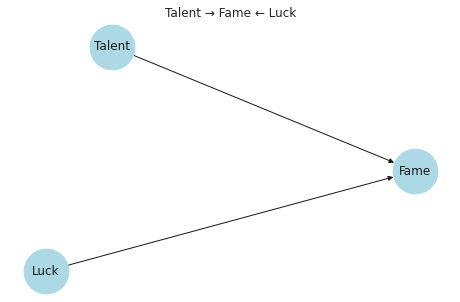

In [19]:
edges_collider = [('Talent', 'Fame'), ('Luck', 'Fame')]
draw_dag(edges_collider, title="Talent → Fame ← Luck")

Here, **Talent** and **Luck** are independent unless you condition on **Fame**.

**Interpretation**: `Talent ⊥ Luck` but `Talent ⊥̸ Luck | Fame` (conditioning opens the path).

## Summary

- **Chains and forks** become **blocked** when you condition on the middle node.
- **Colliders** become **active** when you condition on the middle node.
- d-Separation is a **graphical test** for conditional independence.

Next: We'll use this knowledge to guide variable selection when estimating causal effects.


# Practical examples of conditioning on the middle

## Causal Chain: A → B → C

Chain: corr(A, C) = 0.5613329824871417
Chain: corr(A, C | B) = -0.018151421396109764


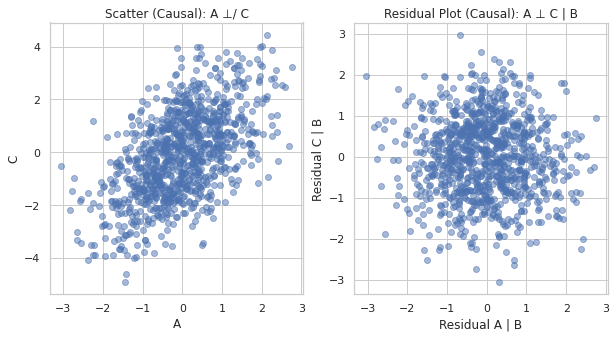

In [143]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

np.random.seed(0)
n = 1000

# A causes B, and B causes C
A = np.random.normal(0, 1, n)
B = A + np.random.normal(0, 1, n)
C = B + np.random.normal(0, 1, n)

df_chain = pd.DataFrame({'A': A, 'B': B, 'C': C})

# Correlation between A and C (unconditioned)
print("Chain: corr(A, C) =", pearsonr(df_chain['A'], df_chain['C'])[0])

# Residuals of A and C after removing B (conditioning on B)
from sklearn.linear_model import LinearRegression

# the part of x not explained by Z
def residualize(x, Z):
    model = LinearRegression().fit(Z, x)
    x_Z = model.predict(Z)
    return x - x_Z

resid_C = residualize(df_chain[['C']], df_chain[['B']])

fig, ax = plt.subplots(ncols=2, figsize=(10, 5))
ax[0].scatter(A, C, alpha=0.5)
ax[0].set_title("Scatter (Causal): A ⊥/ C")
ax[0].set_xlabel("A")
ax[0].set_ylabel("C")
ax[1].scatter(A, resid_C, alpha=0.5)
ax[1].set_title("Residual Plot (Causal): A ⊥ C | B")
ax[1].set_xlabel("Residual A | B")
ax[1].set_ylabel("Residual C | B")

print("Chain: corr(A, C | B) =", pearsonr(A.squeeze(), resid_C.squeeze())[0])


## Fork (Confounding): A ← B → C

Fork: corr(A, C) = 0.5061598504695448
Fork: corr(A, C | B) = -0.0010978732990046022


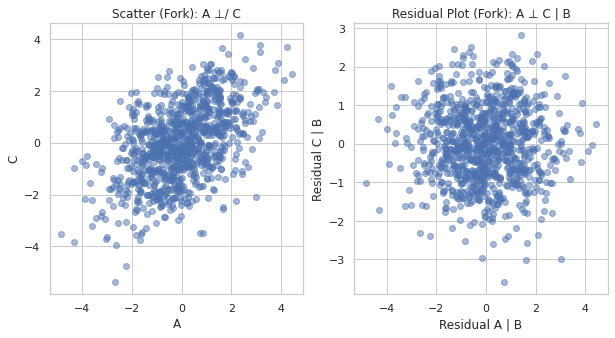

In [170]:
# B causes both A and C
B = np.random.normal(0, 1, n)
A = B + np.random.normal(0, 1, n)
C = B + np.random.normal(0, 1, n)

df_fork = pd.DataFrame({'A': A, 'B': B, 'C': C})

print("Fork: corr(A, C) =", pearsonr(df_fork['A'], df_fork['C'])[0])

resid_C = residualize(df_fork[['C']], df_fork[['B']])

fig, ax = plt.subplots(ncols=2, figsize=(10, 5))
ax[0].scatter(A, C, alpha=0.5)
ax[0].set_title("Scatter (Fork): A ⊥/ C")
ax[0].set_xlabel("A")
ax[0].set_ylabel("C")
ax[1].scatter(A, resid_C, alpha=0.5)
ax[1].set_title("Residual Plot (Fork): A ⊥ C | B")
ax[1].set_xlabel("Residual A | B")
ax[1].set_ylabel("Residual C | B")

print("Fork: corr(A, C | B) =", pearsonr(A.squeeze(), resid_C.squeeze())[0])


## Collider: A → B ← C

Collider: corr(A, C) = -0.028179950846113324
Collider: corr(A, C | B) = -0.43810609312487003


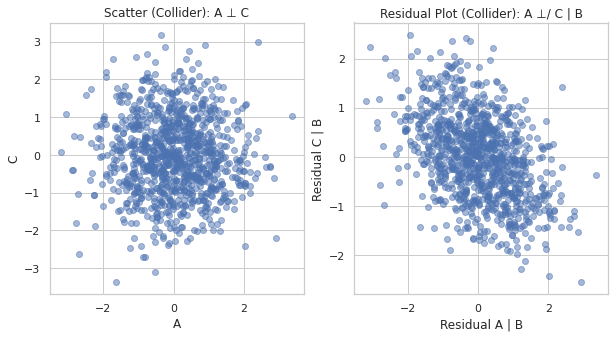

In [183]:
# A and C cause B, but A and C are otherwise independent
A = np.random.normal(0, 1, n)
C = np.random.normal(0, 1, n)
B = A + C + np.random.normal(0, 1, n)

df_collider = pd.DataFrame({'A': A, 'B': B, 'C': C})

print("Collider: corr(A, C) =", pearsonr(df_collider['A'], df_collider['C'])[0])

resid_C = residualize(df_collider[['C']], df_collider[['B']])

fig, ax = plt.subplots(ncols=2, figsize=(10, 5))
ax[0].scatter(A, C, alpha=0.5)
ax[0].set_title("Scatter (Collider): A ⊥ C")
ax[0].set_xlabel("A")
ax[0].set_ylabel("C")
ax[1].scatter(A, resid_C, alpha=0.5)
ax[1].set_title("Residual Plot (Collider): A ⊥/ C | B")
ax[1].set_xlabel("Residual A | B")
ax[1].set_ylabel("Residual C | B")

print("Collider: corr(A, C | B) =", pearsonr(A.squeeze(), resid_C.squeeze())[0])


# Estimating Causal Effects Using Backdoor Adjustment

## Objectives
- Understand the backdoor criterion.
- Use the `DoWhy` library to estimate causal effects.
- Apply these concepts to a simulated dataset.


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dowhy import CausalModel

np.random.seed(42)


##  Simulate Data with a Backdoor Path

In [25]:
# B is a confounder for both T (treatment) and Y (outcome)
n = 1000
B = np.random.normal(size=n)
T = 0.5 * B + np.random.normal(size=n)
Y = 2 * T + 1.5 * B**2 + np.random.normal(size=n)

df = pd.DataFrame({"B": B, "T": T, "Y": Y})
df.head()

,B,T,Y
0,0.496714,1.647713,2.990334
1,-0.138264,0.855502,1.595160
2,0.647689,0.383475,0.603780
3,1.523030,0.114578,3.400625
4,-0.234153,0.581147,-0.649080


## Causal DAG

We simulate the following DAG:

```
B → T → Y
B → Y
```

- B is a confounder that opens a backdoor path from T to Y.
- To estimate the causal effect of T on Y, we need to adjust for B.


##  Define Causal Model

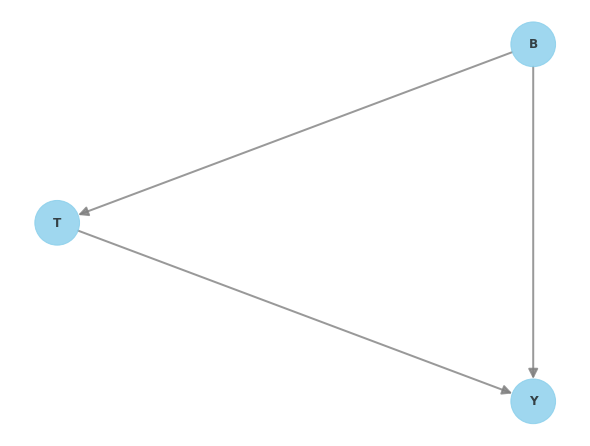

In [26]:
model = CausalModel(
    data=df,
    treatment="T",
    outcome="Y",
    common_causes=["B"]
)
model.view_model(layout="dot")  # This saves a causal_model.png image

##  Identify Estimand

In [27]:
identified_estimand = model.identify_effect()
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
 d          
────(E[Y|B])
d[T]        
Estimand assumption 1, Unconfoundedness: If U→{T} and U→Y then P(Y|T,B,U) = P(Y|T,B)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!



##  Estimate Causal Effect

In [28]:
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression"
)
print("Estimated Causal Effect:", estimate.value)

Estimated Causal Effect: 2.0493310359416723


##  Summary

- Using the backdoor criterion, we controlled for the confounding variable B.
- This gave us an unbiased estimate of the causal effect of T on Y.
- `DoWhy` makes it easy to define a causal model, identify, and estimate effects clearly.


# Estimating Causal Effect: Linear vs Nonlinear Conditioning

##  Objectives
- Simulate a scenario where a confounder affects the outcome nonlinearly.
- Estimate the causal effect of a treatment using linear and nonlinear models.
- Compare estimates to the true causal effect.


In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)


## Simulate Data

In [101]:
n = 100
Z = np.random.uniform(-3, 3, size=n)
T = np.random.normal(0, 1, size=n)
true_effect = 2
Y = true_effect * T - np.abs(Z**2) + 0.1 * np.random.normal(size=n)

df = pd.DataFrame({'Z': Z, 'T': T, 'Y': Y})
df.head()

,Z,T,Y
0,0.358931,1.160806,2.051914
1,-0.935192,0.373513,-0.189065
2,1.888062,-0.295154,-4.084088
3,2.704755,0.558983,-6.068300
4,-0.576489,-0.667354,-1.606150


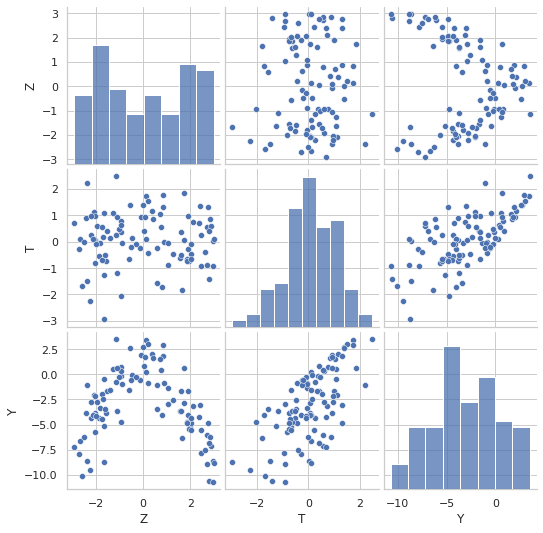

In [113]:
sns.pairplot(df)

##  Estimate Causal Effect Using Linear Regression

In [125]:
model_lin = LinearRegression().fit(df[['T', 'Z']], df['Y'])
lin_coef = model_lin.coef_[0]
print("Linear estimate of treatment effect:", lin_coef)

Linear estimate of treatment effect: 2.274944307076719


## Estimate Causal Effect Using Random Forest

In [126]:
model_rf = RandomForestRegressor().fit(df[['T', 'Z']], df['Y'])

# Estimate effect of increasing T by 1 unit while holding Z fixed
df_plus = df.copy()
dT = 0.1
df_plus['T'] += dT

y_pred_base = model_rf.predict(df[['T', 'Z']])
y_pred_plus = model_rf.predict(df_plus[['T', 'Z']])
rf_effect = np.mean((y_pred_plus - y_pred_base) / dT)

print("Random Forest estimate of treatment effect:", rf_effect)

Random Forest estimate of treatment effect: 1.9983070709003448


##  Summary

- **True causal effect** of T on Y is 2.
- **Linear regression** underestimates the effect due to misspecifying the nonlinearity in Z.
- **Random Forest** captures the nonlinearity and gives a more accurate estimate.

This illustrates why it's crucial to use flexible models when confounders affect outcomes nonlinearly.


# Causal inference vs causal discovery

Two main approaches

1. Causal inference

    Use data to understand causal relations given DAG.
    

2. Causal discovery

    Use data to discover DAG.

Example of causal discovery tools:

https://www.pywhy.org/dowhy/v0.10/example_notebooks/gcm_falsify_dag.html